In [53]:
import json
import pandas as pd

JSON_PATH = "/Users/wangchu/connectivity_analysis/in_exn_2.json"  # or "/Users/wangchu/connectivity_analysis/in_exn.json"

def build_coords_tag_df(json_path):
    with open(json_path, "r") as f:
        data = json.load(f)

    layers = data.get("layers", [])
    rows = []

    for layer in layers:
        if not isinstance(layer, dict):
            continue
        if layer.get("type") != "annotation":
            continue

        name = layer.get("name", None)
        ann_list = layer.get("annotations", [])

        # Only process these two point layers
        if name not in ("annotation1", "annotation2"):
            continue
        if not isinstance(ann_list, list):
            continue

        for ann in ann_list:
            if not isinstance(ann, dict):
                continue

            # Point annotations have "point"; bbox annotations have "pointA"/"pointB" -> skip those
            pt = ann.get("point", None)
            if not (isinstance(pt, (list, tuple)) and len(pt) == 3):
                continue

            x, y, z = map(float, pt)
            tag = ann.get("description", None)

            if name == "annotation1":
                coords = [x / 4.0, y / 4.0, z]
            else:  # annotation2
                coords = [x, y, z]

            rows.append({"coords": coords, "tag": tag})

    return pd.DataFrame(rows, columns=["coords", "tag"])

df_coords_tag = build_coords_tag_df(JSON_PATH)
print("n rows:", len(df_coords_tag))
print(df_coords_tag.head())


n rows: 259
                                              coords            tag
0           [27450.83203125, 5097.560546875, 1701.5]  2, big-radial
1      [27443.25, 4543.361328125, 1701.500244140625]     2, central
2        [27062.673828125, 5015.46044921875, 1901.5]     2, central
3  [25365.15234375, 5108.65673828125, 2051.500244...     2, central
4  [23701.6328125, 4886.6025390625, 1951.50012207...     2, central


In [54]:
df_coords_tag

,coords,tag
0,"[27450.83203125, 5097.560546875, 1701.5]","2, big-radial"
1,"[27443.25, 4543.361328125, 1701.500244140625]","2, central"
2,"[27062.673828125, 5015.46044921875, 1901.5]","2, central"
3,"[25365.15234375, 5108.65673828125, 2051.500244...","2, central"
4,"[23701.6328125, 4886.6025390625, 1951.50012207...","2, central"
...,...,...
254,"[29489.849609375, 2836.979248046875, 1393.5001...",v
255,"[29675.60546875, 2716.126220703125, 1683.50024...",v
256,"[29107.1484375, 2456.5166015625, 1894.50012207...",out
257,"[29706.9375, 2633.31982421875, 1894.5001220703...",v


In [55]:
import numpy as np
from tqdm import tqdm

# Assumes you already have:
#   - df_coords_tag with columns: ["coords", "tag"]
#   - get_seg_id_from_coord(...) defined
#   - spinalcord_seg CloudVolume already initialized (since get_seg_id_from_coord uses it)
MIP = (32, 32, 45)

def _vol_to_root_id(vol):
    """Robustly convert CloudVolume return to a Python int root_id."""
    arr = np.asarray(vol).squeeze()
    if arr.size == 0:
        return np.nan
    try:
        return int(arr.reshape(-1)[0])
    except Exception:
        return np.nan

def append_root_id(df):
    cache = {}  # coords tuple -> root_id
    root_ids = []

    for coords in tqdm(df["coords"].tolist(), desc="Mapping coords -> root_id"):
        # coords is [x, y, z] (already scaled correctly)
        x, y, z = coords
        key = (float(x), float(y), float(z))

        if key in cache:
            root_ids.append(cache[key])
            continue

        try:
            vol = get_seg_id_from_coord((x, y, z), seg_mip=MIP, coordinate_mip=MIP)
            rid = _vol_to_root_id(vol)
        except Exception:
            rid = np.nan

        cache[key] = rid
        root_ids.append(rid)

    out = df.copy()
    out["root_id"] = root_ids
    return out

df_with_root = append_root_id(df_coords_tag)
print(df_with_root.head())
print("NaN root_id count:", int(df_with_root["root_id"].isna().sum()))


Mapping coords -> root_id: 100%|██████████| 259/259 [01:46<00:00,  2.44it/s]

                                              coords            tag  \
0           [27450.83203125, 5097.560546875, 1701.5]  2, big-radial   
1      [27443.25, 4543.361328125, 1701.500244140625]     2, central   
2        [27062.673828125, 5015.46044921875, 1901.5]     2, central   
3  [25365.15234375, 5108.65673828125, 2051.500244...     2, central   
4  [23701.6328125, 4886.6025390625, 1951.50012207...     2, central   

              root_id  
0  720575940888148592  
1  720575940900956101  
2  720575940878978356  
3  720575940861450226  
4  720575940930905464  
NaN root_id count: 0


In [56]:
df_with_root

,coords,tag,root_id
0,"[27450.83203125, 5097.560546875, 1701.5]","2, big-radial",720575940888148592
1,"[27443.25, 4543.361328125, 1701.500244140625]","2, central",720575940900956101
2,"[27062.673828125, 5015.46044921875, 1901.5]","2, central",720575940878978356
3,"[25365.15234375, 5108.65673828125, 2051.500244...","2, central",720575940861450226
4,"[23701.6328125, 4886.6025390625, 1951.50012207...","2, central",720575940930905464
...,...,...,...
254,"[29489.849609375, 2836.979248046875, 1393.5001...",v,720575940909797811
255,"[29675.60546875, 2716.126220703125, 1683.50024...",v,720575940880935569
256,"[29107.1484375, 2456.5166015625, 1894.50012207...",out,720575940881619651
257,"[29706.9375, 2633.31982421875, 1894.5001220703...",v,720575940922795818


In [57]:
import numpy as np
import pandas as pd

# Assumes df_with_root has columns: coords (list [x,y,z]), tag, root_id

def filter_inhibitory_y(df, y_thresh=5435):
    out = df.copy()

    # Extract y from coords
    out["y"] = out["coords"].apply(lambda c: float(c[1]) if isinstance(c, (list, tuple)) and len(c) == 3 else np.nan)

    # Tag starts with "in" (case-insensitive), allowing "in", "in, islet", "in, psi", etc.
    tag_str = out["tag"].fillna("").astype(str).str.strip().str.lower()
    is_inhibitory = tag_str.str.startswith("in")

    # y < threshold
    y_ok = out["y"] < float(y_thresh)

    filtered = out[is_inhibitory & y_ok].copy()

    # If you truly want only coords+tag+root_id, drop the helper y column:
    # filtered = filtered.drop(columns=["y"])

    return filtered

inhibitory_filtered_df = filter_inhibitory_y(df_with_root, y_thresh=5435)
print("n inhibitory (y<5435):", len(inhibitory_filtered_df))
print(inhibitory_filtered_df.head())


n inhibitory (y<5435): 31
                                               coords        tag  \
16  [26358.693359375, 3289.394775390625, 1701.5002...  in, islet   
21  [26196.8203125, 5398.8798828125, 1701.50024414...         in   
26  [25503.1484375, 5343.93505859375, 1701.5002441...    in, psi   
38  [24104.521484375, 3595.27978515625, 1701.50012...  in, islet   
58  [27381.15625, 3256.225830078125, 1751.50012207...         in   

               root_id            y  
16  720575940929601786  3289.394775  
21  720575940929614625  5398.879883  
26  720575940879811062  5343.935059  
38  720575940893307467  3595.279785  
58  720575940882706332  3256.225830  


In [58]:
inhibitory_filtered_df

,coords,tag,root_id,y
16,"[26358.693359375, 3289.394775390625, 1701.5002...","in, islet",720575940929601786,3289.394775
21,"[26196.8203125, 5398.8798828125, 1701.50024414...",in,720575940929614625,5398.879883
26,"[25503.1484375, 5343.93505859375, 1701.5002441...","in, psi",720575940879811062,5343.935059
38,"[24104.521484375, 3595.27978515625, 1701.50012...","in, islet",720575940893307467,3595.279785
58,"[27381.15625, 3256.225830078125, 1751.50012207...",in,720575940882706332,3256.225830
72,"[27541.421875, 4851.64404296875, 1851.5]",in,720575940885542524,4851.644043
76,"[23992.345703125, 4490.1181640625, 1851.499877...","in, psi",720575940869591310,4490.118164
77,"[24297.25, 4556.66015625, 1851.4998779296875]","in, islet",720575940900300153,4556.660156
81,"[27988.498046875, 4957.74365234375, 1851.5]","in, inhibit-v",720575940897365506,4957.743652
102,"[27637.314453125, 3845.156494140625, 1951.5001...","in, inhibit-v",720575940888983158,3845.156494


In [59]:
# Libraries
import caveclient
import subprocess
import json
import numpy as np
import matplotlib.pyplot as plt
import cloudvolume
from tqdm import tqdm
import glob
import os

# Setup caveclient
client = caveclient.CAVEclient("wclee_mouse_spinalcord_cltmr", ) #server_address='https://global.daf-apis.com')

In [60]:
exn_tag = client.materialize.query_table('spinalcord_neuron_clusters_2')

Query was executed using streaming via CSV, which can mangle types. Please upgrade to caveclient > 8.0.0 to avoid type mangling. Because you may have been affected by mangled types, this change is breaking, but it should provide an improved experience.


In [61]:
exn_tag

,id,created,superceded_id,valid,tag,pt_supervoxel_id,pt_root_id,pt_position
0,1,2026-01-13 05:03:23.816897+00:00,NaN,t,p2_noci,77053912649181423,720575940865160474,"[22364, 2792, 812]"
1,2,2026-01-13 05:03:23.817627+00:00,NaN,t,p2_noci,80853826042750294,720575940881844049,"[36293, 2701, 3171]"
2,3,2026-01-13 05:03:23.818312+00:00,NaN,t,p2_noci,82824356568335590,720575940902401208,"[43341, 3453, 2176]"
3,4,2026-01-13 05:03:23.818956+00:00,NaN,t,p2_noci,72479876497660276,720575940896702138,"[5689, 2462, 2592]"
4,5,2026-01-13 05:03:23.819582+00:00,NaN,t,p2_noci,78953868540584103,720575940898432765,"[29367, 2807, 368]"
...,...,...,...,...,...,...,...,...
218,219,2026-01-13 05:03:23.948465+00:00,NaN,t,r,78180156623161798,720575940894664404,"[26383, 3997, 1701]"
219,220,2026-01-13 05:03:23.949048+00:00,NaN,t,r,78109650440024886,720575940903415565,"[26118, 3477, 1701]"
220,221,2026-01-13 05:03:23.949608+00:00,NaN,t,r,77476263022984897,720575940875854397,"[23885, 3254, 1751]"
221,222,2026-01-13 05:03:23.950224+00:00,NaN,t,r,77898750500149038,720575940910295881,"[25559, 4188, 2001]"


In [62]:
import pandas as pd

# inhibitory_filtered_df: has column "root_id"
# exn_tag: has column "pt_root_id"

# 1) Fast set-intersection (gives you the conflicting root IDs)
inhib_ids = set(pd.Series(inhibitory_filtered_df["root_id"]).dropna().astype("int64").tolist())
exn_ids   = set(pd.Series(exn_tag["pt_root_id"]).dropna().astype("int64").tolist())

conflict_root_ids = sorted(inhib_ids.intersection(exn_ids))
print("n conflicting root_ids:", len(conflict_root_ids))
print("conflicting root_ids:", conflict_root_ids[:50], "..." if len(conflict_root_ids) > 50 else "")

# 2) If you want the actual rows from BOTH tables for the conflicting neurons:
inhib_conflicts = inhibitory_filtered_df[
    inhibitory_filtered_df["root_id"].notna()
    & inhibitory_filtered_df["root_id"].astype("int64").isin(conflict_root_ids)
].copy()

exn_conflicts = exn_tag[
    exn_tag["pt_root_id"].notna()
    & exn_tag["pt_root_id"].astype("int64").isin(conflict_root_ids)
].copy()

print("\n--- inhibitory rows (conflicts) ---")
print(inhib_conflicts.head())

print("\n--- excitatory rows (conflicts) ---")
print(exn_conflicts.head())

# 3) Optional: single merged view (one row per matched pair)
merged_conflicts = exn_conflicts.merge(
    inhib_conflicts,
    left_on="pt_root_id",
    right_on="root_id",
    how="inner",
    suffixes=("_exn", "_inhib")
)

print("\n--- merged conflicts ---")
print(merged_conflicts.head())


n conflicting root_ids: 0
conflicting root_ids: [] 

--- inhibitory rows (conflicts) ---
Empty DataFrame
Columns: [coords, tag, root_id, y]
Index: []

--- excitatory rows (conflicts) ---
Empty DataFrame
Columns: [id, created, superceded_id, valid, tag, pt_supervoxel_id, pt_root_id, pt_position]
Index: []

--- merged conflicts ---
Empty DataFrame
Columns: [id, created, superceded_id, valid, tag_exn, pt_supervoxel_id, pt_root_id, pt_position, coords, tag_inhib, root_id, y]
Index: []


In [63]:
set(exn_tag['tag'])

{'adltmr_module',
 'cltmr_module',
 'noci_module',
 'np_module',
 'p1',
 'p2_cold',
 'p2_noci',
 'p2_poly',
 'r',
 'v1',
 'v2'}

In [64]:
# Number of neurons (unique pt_root_id) per tag in exn_tag

exn_tag_counts = (
    exn_tag.dropna(subset=["pt_root_id"])
          .assign(tag=exn_tag["tag"].fillna("NA").astype(str))
          .groupby("tag")["pt_root_id"]
          .nunique()
          .sort_values(ascending=False)
)

print(exn_tag_counts)


tag
v1               41
v2               36
np_module        27
cltmr_module     24
r                24
p2_noci          16
adltmr_module    15
p2_poly          15
noci_module      10
p2_cold           9
p1                6
Name: pt_root_id, dtype: int64


In [65]:
import numpy as np
import pandas as pd

# Assumes you have:
# - exn_tag with columns: pt_root_id, pt_position (=[x,y,z]), tag
# - inhibitory_filtered_df with columns: root_id, coords (=[x,y,z]), tag

def filter_exn_bbox(exn_tag, x_min=22650, x_max=29950, y_max=5435, z_min=1340, z_max=2060):
    exn = exn_tag.copy()

    # pt_position is [x,y,z]
    pos = exn["pt_position"].apply(
        lambda p: p if isinstance(p, (list, tuple, np.ndarray)) and len(p) == 3 else [np.nan, np.nan, np.nan]
    )
    exn["x"] = pos.apply(lambda p: float(p[0]))
    exn["y"] = pos.apply(lambda p: float(p[1]))
    exn["z"] = pos.apply(lambda p: float(p[2]))

    exn_f = exn[
        (exn["x"] > x_min) & (exn["x"] < x_max) &
        (exn["y"] < y_max) &
        (exn["z"] > z_min) & (exn["z"] < z_max)
    ].copy()

    # unify columns
    exn_f = exn_f.rename(columns={"pt_root_id": "root_id", "pt_position": "coords"})
    exn_f = exn_f[["root_id", "coords", "tag"]]
    return exn_f

# 1) Filter exn_tag by bbox + z
exn_filtered_df = filter_exn_bbox(exn_tag, x_min=22650, x_max=29950, y_max=5450, z_min=1300, z_max=2100)

# 2) Unify inhibitory df columns
inhib_unified_df = inhibitory_filtered_df[["root_id", "coords", "tag"]].copy()

# 3) Combine
combined_df = pd.concat([exn_filtered_df, inhib_unified_df], ignore_index=True)

print("exn filtered n:", len(exn_filtered_df))
print("inhib filtered n:", len(inhib_unified_df))
print("combined n:", len(combined_df))
print(combined_df.head())


exn filtered n: 124
inhib filtered n: 31
combined n: 155
              root_id               coords          tag
0  720575940889967848  [26998, 2358, 1654]      p2_poly
1  720575940869481691  [27727, 3165, 1749]    np_module
2  720575940894664201  [22764, 2181, 1856]      p2_cold
3  720575940941106028  [29347, 3155, 1813]  noci_module
4  720575940922949405  [23048, 3069, 1851]  noci_module


In [66]:
combined_df

,root_id,coords,tag
0,720575940889967848,"[26998, 2358, 1654]",p2_poly
1,720575940869481691,"[27727, 3165, 1749]",np_module
2,720575940894664201,"[22764, 2181, 1856]",p2_cold
3,720575940941106028,"[29347, 3155, 1813]",noci_module
4,720575940922949405,"[23048, 3069, 1851]",noci_module
...,...,...,...
150,720575940917382422,"[28678.2578125, 5244.25732421875, 1901.5]",in
151,720575940862186599,"[23522.869140625, 2903.47705078125, 1525.5]",in
152,720575940898475005,"[24303.755859375, 2498.508544921875, 1483.5001...",in
153,720575940868527768,"[23090.791015625, 2356.212158203125, 1356.5]",in


In [67]:
# Counts of neurons per tag in combined_df

# 1) row counts per tag (each row = one neuron entry in your tables)
tag_counts = combined_df["tag"].fillna("NA").astype(str).value_counts()
print(tag_counts)

# 2) unique neuron (root_id) counts per tag (safer if any duplicates exist)
unique_neuron_counts = (
    combined_df.dropna(subset=["root_id"])
    .assign(tag=combined_df["tag"].fillna("NA").astype(str))
    .groupby("tag")["root_id"]
    .nunique()
    .sort_values(ascending=False)
)
print("\nUnique root_id per tag:")
print(unique_neuron_counts)


tag
np_module        27
cltmr_module     24
r                24
in               16
adltmr_module    15
v2               12
noci_module      10
v1               10
in, islet         9
in, inhibit-v     4
in, psi           2
p2_poly           1
p2_cold           1
Name: count, dtype: int64

Unique root_id per tag:
tag
np_module        27
cltmr_module     24
r                24
in               16
adltmr_module    15
v2               12
noci_module      10
v1               10
in, islet         9
in, inhibit-v     4
in, psi           2
p2_cold           1
p2_poly           1
Name: root_id, dtype: int64


Saved: neurons_xy_distribution_0219.svg


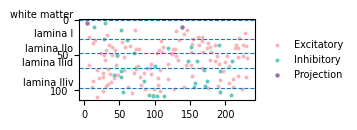

In [68]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------
# Config
# -----------------------
SAVE_SVG = True
SVG_PATH = "neurons_xy_distribution_0219.svg"

# Colors
COL_EXC  = "#f8b6ba"
COL_INH  = "#62c6bf"
COL_PROJ = "#9a72aa"

# Reference origins (voxel coords)
X0 = 22650   # x origin
Y0 = 2040    # y origin (white matter)

# nm per voxel in x/y = 32 nm; convert to um: *32/1000
VOX_TO_UM_XY = 32.0 / 1000.0

# Lamina boundaries in ORIGINAL y (voxel coords)
LAMINA_LINES_Y = [
    (2040, "white matter"),
    (2900, "lamina I"),
    (3530, "lamina IIo"),
    (4150, "lamina IIid"),
    (5050, "lamina IIiv"),
]

# -----------------------
# Prepare XY + class
# -----------------------
df = combined_df.copy()
df["x"] = df["coords"].apply(lambda c: float(c[0]))
df["y"] = df["coords"].apply(lambda c: float(c[1]))

# Re-zero + convert to µm
df["x_um"] = (df["x"] - X0) * VOX_TO_UM_XY
df["y_um"] = (df["y"] - Y0) * VOX_TO_UM_XY

tag = df["tag"].fillna("").astype(str).str.strip().str.lower()
is_proj = tag.isin(["p2_cold", "p2_poly"])
is_inh  = tag.str.startswith("in")
is_exc  = ~(is_proj | is_inh)

# Convert lamina line y's to the same µm coordinate system
lamina_lines_um = [((yv - Y0) * VOX_TO_UM_XY, name) for yv, name in LAMINA_LINES_Y]

# -----------------------
# Plot (8 cm x 8 cm)
# -----------------------
fig_w_in = 8 / 2.54
fig_h_in = 8 / 2.54
fig, ax = plt.subplots(figsize=(fig_w_in, fig_h_in))

ax.scatter(df.loc[is_exc,  "x_um"], df.loc[is_exc,  "y_um"], s=8,  c=COL_EXC,  label="Excitatory",  linewidths=0)
ax.scatter(df.loc[is_inh,  "x_um"], df.loc[is_inh,  "y_um"], s=8,  c=COL_INH,  label="Inhibitory",  linewidths=0)
ax.scatter(df.loc[is_proj, "x_um"], df.loc[is_proj, "y_um"], s=10, c=COL_PROJ, label="Projection", linewidths=0)

# Lamina dashed lines + labels OUTSIDE the axes (left side to avoid legend overlap)
for y_um, name in lamina_lines_um:
    ax.axhline(y_um, linestyle="--", linewidth=0.8)
    ax.text(
        -0.03, y_um, name,
        transform=ax.get_yaxis_transform(),   # x in axes fraction, y in data coords
        ha="right", va="bottom",
        fontsize=7,
        clip_on=False
    )

#ax.set_xlabel("x (µm from 22650)")
#ax.set_ylabel("y (µm from white matter at 2040)")
ax.tick_params(labelsize=7)

# Flip y axis so smaller values (closer to white matter) are at the top
ax.invert_yaxis()

# Keep equal scaling in x/y (no distortion)
ax.set_aspect("equal", adjustable="box")

# Legend outside (right)
ax.legend(frameon=False, fontsize=7, loc="center left", bbox_to_anchor=(1.02, 0.5))

# Leave room for left-side lamina labels and right-side legend
plt.subplots_adjust(left=0.22, right=0.78)

if SAVE_SVG:
    fig.savefig(SVG_PATH, format="svg", bbox_inches="tight")
    print("Saved:", SVG_PATH)

plt.show()


Saved: vertical_vs_projection_distribution.svg


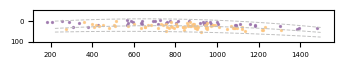

In [52]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline

# ----------------------------
# Config
# ----------------------------
SAVE_SVG = True
SVG_PATH = "vertical_vs_projection_distribution.svg"

# Resolution in nanometers (same as your example)
x_res = 32
y_res = 32

# Same Y-offset convention as your example
y_offset_um = (2300 * y_res) / 1000  # 2300 px → 73.6 µm

# Tags
proj_tags = {"p1", "p2_cold", "p2_noci", "p2_poly"}
vert_tags = {"v1", "v2"}

# Colors (you can change if you want)
COL_PROJ = "#9a72aa"   # same style as your example for pn
COL_VERT = "#fdc57e"  # same style as your example for v

# ----------------------------
# Helper: (x,y,z) px -> um (with Y offset)
# ----------------------------
def pts_to_um(pts):
    pts = np.asarray(pts, dtype=np.float64)
    x = (pts[:, 0] * x_res) / 1000.0
    y = ((pts[:, 1] * y_res) / 1000.0) - y_offset_um
    return x, y

# Curved dashed boundary (same as your example)
def process_curve(ax, control_pts_px, color="silver"):
    control_pts_px = np.asarray(control_pts_px, dtype=np.float64)
    scaled = control_pts_px * np.array([x_res, y_res]) / 1000.0  # -> µm
    x = scaled[:, 0]
    y = scaled[:, 1] - y_offset_um
    x_smooth = np.linspace(x.min(), x.max(), 300)
    spline = make_interp_spline(x, y, k=2)
    y_smooth = spline(x_smooth)
    ax.plot(x_smooth, y_smooth, linestyle="--", color=color, linewidth=0.7)

# ----------------------------
# Extract positions from exn_tag
# ----------------------------
tag_series = exn_tag["tag"].fillna("").astype(str).str.strip().str.lower()

proj_pts = exn_tag.loc[tag_series.isin(proj_tags), "pt_position"].tolist()
vert_pts = exn_tag.loc[tag_series.isin(vert_tags), "pt_position"].tolist()

# Convert to µm
p_x, p_y = pts_to_um(proj_pts) if len(proj_pts) else (np.array([]), np.array([]))
v_x, v_y = pts_to_um(vert_pts) if len(vert_pts) else (np.array([]), np.array([]))

# ----------------------------
# Plot (same size style as your example: ~9cm x 8cm)
# ----------------------------
fig, ax = plt.subplots(figsize=(9/2.54, 8/2.54))

ax.scatter(p_x, p_y, color=COL_PROJ, label="Projection (p1/p2_*)", s=1.8, alpha=0.8)
ax.scatter(v_x, v_y, color=COL_VERT, label="Vertical (v1/v2)",      s=1.8, alpha=0.8)

# Dashed curved boundaries (copy/paste from your example)
process_curve(ax, np.array([[6896, 2306], [25227, 2000], [46840, 3257]]), "silver")
process_curve(ax, np.array([[6896, 3400], [25227, 3000], [46840, 4000]]), "silver")
process_curve(ax, np.array([[6896, 3950], [25227, 3900], [46840, 4700]]), "silver")
#process_curve(ax, np.array([[6896, 4900], [25227, 5100], [46840, 6000]]), "silver")

# Axes formatting
ax.set_aspect("equal")
ax.grid(False)
ax.tick_params(axis="both", which="major", labelsize=5)

# Set Y limits like your example (inverted by max->min)
all_y = np.concatenate([p_y, v_y]) if (len(p_y) + len(v_y)) else np.array([0.0])
ax.set_ylim(all_y.max() + 50, all_y.min() - 50)

plt.tight_layout()

if SAVE_SVG:
    plt.savefig(SVG_PATH, format="svg", dpi=600)
    print("Saved:", SVG_PATH)

plt.show()
